### Notebook 02 — Neural Bigram

#### Introdução

No notebook anterior construímos um modelo de linguagem baseado em contagens.

Ele aprendia observando quantas vezes um token aparecia após outro.

Por exemplo:

- o → l : 5 vezes
- o → espaço : 3 vezes

A partir dessas contagens calculávamos probabilidades.

Esse modelo funciona, mas possui limitações importantes.

Ele apenas memoriza o que observou durante o treinamento.

Neste notebook construiremos uma versão neural do mesmo modelo.

Ao invés de armazenar contagens explicitamente, utilizaremos parâmetros treináveis capazes de aprender essas relações automaticamente.

Essa mudança introduz vários conceitos fundamentais do Deep Learning:

- Pesos
- Matrizes
- Logits
- Softmax
- Loss
- Gradientes
- Backpropagation

Ao final deste notebook você terá treinado sua primeira rede neural para prever o próximo token.

### 1. Revisando o Modelo Anterior

#### Objetivo

Antes de avançarmos, vamos revisar rapidamente como funcionava nosso primeiro modelo.

O Bigram Language Model clássico aprendia observando pares de tokens consecutivos.

Exemplo:

Texto:

"ola"

Bigramas:

(o, l)

(l, a)

---

#### Como ele fazia previsões?

Depois de contar todas as ocorrências do dataset, o modelo construía uma tabela de probabilidades.

Exemplo:

Depois de "o":

- l → 75%
- espaço → 25%

Quando precisava gerar texto, ele consultava essa tabela e escolhia uma das opções disponíveis.

---

#### Fluxo completo

Texto
↓
Tokenização
↓
Contagem de Bigramas
↓
Probabilidades
↓
Geração de Texto

In [510]:
# ==================================================
# SEÇÃO 1 - REVISÃO
# ==================================================

print("Fluxo do modelo anterior:")

print("""
Texto
 ↓
Tokenização
 ↓
Contagem
 ↓
Probabilidades
 ↓
Geração
""")

Fluxo do modelo anterior:

Texto
 ↓
Tokenização
 ↓
Contagem
 ↓
Probabilidades
 ↓
Geração



#### Exercício de Reflexão

Imagine que o dataset contenha apenas:

"bom dia"

e

"boa noite"

Pergunta:

Após observar a letra "b", o modelo sabe qual frase está sendo construída?

Por quê?

#### Conceito Importante

O modelo clássico não possui compreensão.

Ele apenas consulta frequências observadas anteriormente.

Seu conhecimento está armazenado diretamente nas contagens.

### 2. O Problema do Bigrama Clássico

#### Objetivo

Entender por que precisamos de uma abordagem diferente.

O modelo baseado em contagens funciona bem para exemplos pequenos.

Mas apresenta limitações importantes quando o vocabulário cresce.

---

#### Imagine um vocabulário com 50.000 tokens

Para cada token precisaríamos armazenar informações sobre todos os possíveis próximos tokens.

O número de combinações cresce rapidamente.

Além disso, o modelo apenas memoriza frequências.

Ele não aprende representações mais gerais da linguagem.

---

#### O que queremos?

Queremos um sistema capaz de aprender sozinho.

Ao invés de armazenar contagens diretamente, queremos armazenar parâmetros ajustáveis.

Esses parâmetros serão modificados durante o treinamento.

É exatamente isso que uma rede neural faz.

In [511]:
# ==================================================
# SEÇÃO 2 - ESCALA
# ==================================================

vocab_exemplo = 50_000

possiveis_transicoes = vocab_exemplo * vocab_exemplo

print(
    f"Possíveis transições: {possiveis_transicoes:,}"
)

Possíveis transições: 2,500,000,000


#### Exercício de Reflexão

Imagine um vocabulário com milhões de tokens.

Pergunta:

Memorizar todas as transições continua sendo uma boa estratégia?

Quais problemas poderiam surgir?

#### Conceito Importante

Grande parte da evolução da IA pode ser vista como uma tentativa de substituir tabelas explícitas por representações aprendidas automaticamente.

### 3. Introdução aos Parâmetros Treináveis

#### Objetivo

Compreender a principal diferença entre um modelo clássico e uma rede neural.

No modelo anterior armazenávamos contagens.

Agora armazenaremos pesos.

---

#### O que é um peso?

Um peso é simplesmente um número ajustável.

Durante o treinamento esses números serão modificados.

O objetivo é fazer com que o modelo produza previsões cada vez melhores.

---

#### Uma analogia

Imagine uma mesa de som.

Cada botão pode aumentar ou diminuir um aspecto do áudio.

Uma rede neural funciona de maneira parecida.

O treinamento ajusta milhares ou milhões desses "botões" automaticamente.

In [512]:
# ==================================================
# SEÇÃO 3 - PESOS
# ==================================================

import torch

peso = torch.tensor(0.5)

print("Peso inicial:")
print(peso)

Peso inicial:
tensor(0.5000)


#### Exercício de Reflexão

Se um peso influencia uma previsão incorreta, o que deveria acontecer com ele?

Ele deveria permanecer igual ou ser ajustado?

Por quê?

#### Conceito Importante

Aprender significa ajustar parâmetros.

Toda rede neural, independentemente do tamanho, aprende modificando pesos ao longo do treinamento.

### 4. Preparando o Ambiente Neural

#### Objetivo

Antes de criarmos nossa primeira rede neural, precisamos reconstruir algumas estruturas básicas utilizadas no notebook anterior.

Isso permitirá que este notebook seja executado de forma independente.

Além disso, prepararemos os dados para utilização com PyTorch.

---

#### O que vamos criar?

Precisamos de:

- Dataset
- Vocabulário
- Tokenização
- Sequência Numérica
- Tensor PyTorch

Esses elementos serão utilizados durante todo o treinamento.

---

#### Por que estamos repetindo isso?

No notebook anterior utilizávamos listas Python comuns.

Agora entraremos no mundo do Deep Learning.

Para isso precisaremos representar nossos dados utilizando tensores do PyTorch.

In [513]:
# ==================================================
# SEÇÃO 4 - SETUP
# ==================================================

import torch

with open("../../data/input.txt", "r", encoding="utf-8") as f:
    text = f.read()

chars = sorted(list(set(text)))

vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join([itos[i] for i in ids])

data = torch.tensor(
    encode(text),
    dtype=torch.long
)

print(f"Dataset size: {len(data)}")
print(f"Vocabulary size: {vocab_size}")

Dataset size: 52
Vocabulary size: 16


#### Exercício de Reflexão

Observe o tipo da variável `data`.

Pergunta:

Por que estamos utilizando um tensor do PyTorch em vez de uma lista Python comum?

O que uma biblioteca de Deep Learning pode oferecer além do simples armazenamento de números?

#### Conceito Importante

Deep Learning é construído sobre operações matemáticas realizadas em tensores.

Um tensor pode ser visto como uma generalização de:

- Escalares
- Vetores
- Matrizes

Praticamente tudo que uma rede neural faz consiste em transformar tensores em outros tensores.

### 5. Criando Nossa Primeira Matriz de Pesos

#### Objetivo

No notebook anterior utilizávamos uma tabela de contagens.

Agora vamos substituí-la por uma matriz de parâmetros treináveis.

Esses parâmetros serão ajustados automaticamente durante o treinamento.

---

#### O que é uma matriz de pesos?

Imagine uma tabela onde:

- Cada linha representa um token atual.
- Cada coluna representa um possível próximo token.

Cada posição contém um número chamado peso.

Inicialmente esses valores são aleatórios.

Durante o treinamento eles serão ajustados para representar padrões da linguagem.

---

#### Comparação

Modelo Clássico:

Token Atual
↓
Tabela de Probabilidades
↓
Próximo Token

Modelo Neural:

Token Atual
↓
Matriz de Pesos
↓
Probabilidades
↓
Próximo Token

In [514]:
# ==================================================
# SEÇÃO 5 - MATRIZ DE PESOS
# ==================================================

w = torch.randn(
    (vocab_size, vocab_size),
    requires_grad=True
)

print(w.shape)

torch.Size([16, 16])


In [515]:
w[:5, :5]

tensor([[-2.3702,  0.3777,  1.6860,  0.2788,  0.3952],
        [-0.2308,  0.2556, -1.3903, -0.5821,  0.8581],
        [-0.6051, -1.7518,  0.5666, -1.1013, -1.0685],
        [ 0.2399,  0.9924, -0.0050, -2.4354, -1.1887],
        [-0.8145,  1.5340,  0.3776,  0.3490, -0.1982]],
       grad_fn=<SliceBackward0>)

#### Exercício de Reflexão

Observe os valores da matriz.

Pergunta:

Esses números possuem algum significado neste momento?

Se todos foram gerados aleatoriamente, como o modelo poderá aprender algo útil a partir deles?

#### Conceito Importante

No início do treinamento a rede não sabe absolutamente nada.

Os pesos são inicializados aleatoriamente.

O aprendizado consiste em modificar esses valores para que as previsões produzidas pela rede se aproximem cada vez mais dos dados observados.

#### Recapitulando

Até agora construímos:

Texto
↓
Tokenização
↓
Tensor
↓
Matriz de Pesos

Ainda não realizamos nenhuma previsão.

Na próxima seção veremos o que acontece quando um token entra na rede neural pela primeira vez.

---

### 6. Fazendo a Primeira Previsão

#### Objetivo

Já criamos nossa primeira matriz de pesos:

$$
w
$$

Ela representa tudo o que a rede sabe.

Neste momento, porém, os pesos são aleatórios.

A rede ainda não aprendeu nada.

Mesmo assim, já podemos utilizá-la para produzir previsões.

---

#### O que entra na rede?

No notebook anterior utilizávamos diretamente o token atual para consultar uma tabela de probabilidades.

Agora faremos algo diferente.

Primeiro transformaremos o token em um vetor.

Depois utilizaremos esse vetor para acessar a matriz de pesos.

---

#### Intuição

Suponha um vocabulário com 5 tokens:

```text
a
b
c
d
e
```

Se o token atual for:

```text
c
```

Podemos representá-lo como:

```text
[0, 0, 1, 0, 0]
```

Essa representação é chamada de One-Hot Encoding.

---

#### O que acontecerá?

O fluxo da rede será:

```text
Token
   ↓
One-Hot
   ↓
Matriz W
   ↓
Scores
```

Esses scores ainda não são probabilidades.

São apenas valores produzidos pela rede.

Mais adiante aprenderemos como transformá-los em probabilidades reais.

In [516]:
# ==================================================
# ESCOLHENDO UM TOKEN DE EXEMPLO
# ==================================================

token_id = stoi['o']

print("Token ID:", token_id)
print("Token:", repr(itos[token_id]))

Token ID: 11
Token: 'o'


In [517]:
# ==================================================
# ONE-HOT ENCODING
# ==================================================

import torch.nn.functional as F

x = F.one_hot(
    torch.tensor(token_id),
    num_classes=vocab_size
).float()

print(x)
print()
print("Shape:", x.shape)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

Shape: torch.Size([16])


In [518]:
# ==================================================
# PRIMEIRA PASSAGEM PELA REDE
# ==================================================

logits = x @ w

print("\nPrimeiros 10 logits:")
print(logits[:10])
print()
print("Shape:", logits.shape)


Primeiros 10 logits:
tensor([-1.4951, -0.3355, -0.1699,  1.0039,  0.5537, -2.0023, -1.8803, -0.3587,
         0.6037, -0.8542], grad_fn=<SliceBackward0>)

Shape: torch.Size([16])


Observe que a saída tem exatamente o mesmo tamanho do vocabulário.

Isso acontece porque a rede está atribuindo um score para cada possível próximo token.

Neste momento esses valores ainda não são probabilidades.
Eles são apenas preferências aprendidas (ou, por enquanto, aleatórias).

#### Exercício de Reflexão

Observe o vetor gerado.

Perguntas:

- Quantos números existem na saída?
- Por que esse número é igual ao tamanho do vocabulário?
- O que cada posição representa?

Pense nisso antes de continuar.

#### Conceito Importante

A saída da rede possui uma posição para cada token do vocabulário.

Neste momento esses valores ainda não representam probabilidades.

Eles são apenas scores produzidos pelos pesos atuais da rede.

Como os pesos foram inicializados aleatoriamente, os scores também são essencialmente aleatórios.

O treinamento servirá justamente para ajustar esses pesos até que os scores passem a refletir padrões reais observados nos dados.

---

### 7. O Que São Logits?

#### Objetivo

Na seção anterior nossa rede produziu um vetor chamado:

```python
logits
```

Exemplo:

```text
tensor([
     1.25,
    -0.73,
     0.91,
     2.40,
    -1.12
])
```

Mas o que esses números significam?

---

#### O que são logits?

Logits são os scores produzidos pela rede neural.

Eles representam o quanto a rede "gosta" de cada possível próximo token.

Porém:

**logits ainda não são probabilidades.**

Observe:

```text
1.25
-0.73
0.91
2.40
-1.12
```

Problemas:

- Existem números negativos
- A soma não é 1
- Não podem ser interpretados como chances

Precisamos transformar esses valores em probabilidades.

---

#### Intuição

Imagine um vocabulário com apenas 3 tokens:

```text
a
b
c
```

A rede produz:

```text
a → 2.0
b → 1.0
c → 0.5
```

Isso significa apenas:

```text
a é mais preferido que b
b é mais preferido que c
```

Nada mais.

Ainda não sabemos as probabilidades.

---

#### O papel do Softmax

O Softmax pega os logits e os transforma em probabilidades.

Ele garante duas propriedades:

1. Todas as probabilidades serão positivas
2. A soma será exatamente 1

Isso permite interpretar a saída da rede como uma distribuição de probabilidade.

---

#### Conexão com o Notebook 01

No bigrama clássico tínhamos:

```text
Contagens
 ↓
Normalização
 ↓
Probabilidades
```

No Neural Bigrama teremos:

```text
Pesos
 ↓
Logits
 ↓
Softmax
 ↓
Probabilidades
```

A ideia continua sendo a mesma.

A diferença é que agora as probabilidades serão aprendidas pela rede.

In [519]:
# ==================================================
# SOFTMAX
# ==================================================

probs = F.softmax(
    logits,
    dim=0
)

print(probs)
print()
print("Soma:", probs.sum())

tensor([0.0105, 0.0334, 0.0395, 0.1276, 0.0814, 0.0063, 0.0071, 0.0327, 0.0855,
        0.0199, 0.0532, 0.0332, 0.0063, 0.0392, 0.4100, 0.0142],
       grad_fn=<SoftmaxBackward0>)

Soma: tensor(1., grad_fn=<SumBackward0>)


In [520]:
# ==================================================
# VISUALIZANDO LOGITS E PROBABILIDADES
# ==================================================

for i in range(vocab_size):

    print(
        f"{repr(itos[i]):>4} | "
        f"logit={logits[i]:7.3f} | "
        f"prob={probs[i]:.4f}"
    )

'\n' | logit= -1.495 | prob=0.0105
 ' ' | logit= -0.336 | prob=0.0334
 'a' | logit= -0.170 | prob=0.0395
 'c' | logit=  1.004 | prob=0.1276
 'd' | logit=  0.554 | prob=0.0814
 'g' | logit= -2.002 | prob=0.0063
 'h' | logit= -1.880 | prob=0.0071
 'i' | logit= -0.359 | prob=0.0327
 'l' | logit=  0.604 | prob=0.0855
 'm' | logit= -0.854 | prob=0.0199
 'n' | logit=  0.129 | prob=0.0532
 'o' | logit= -0.341 | prob=0.0332
 'p' | logit= -2.000 | prob=0.0063
 'r' | logit= -0.177 | prob=0.0392
 't' | logit=  2.171 | prob=0.4100
 'u' | logit= -1.194 | prob=0.0142


#### Exercício de Reflexão

Observe a tabela gerada.

Perguntas:

- O token com maior logit possui a maior probabilidade?
- Todos os valores agora são positivos?
- A soma das probabilidades é exatamente 1?

Por que essas propriedades são importantes para um modelo de linguagem?

#### Conceito Importante

Logits são apenas preferências internas da rede.

Eles não precisam estar entre 0 e 1.

Eles podem ser:

- positivos
- negativos
- grandes
- pequenos

O Softmax converte essas preferências em probabilidades válidas.

Praticamente todos os modelos modernos de classificação e linguagem utilizam esse mesmo padrão:

```text
Rede Neural
     ↓
   Logits
     ↓
  Softmax
     ↓
Probabilidades
```

Você acabou de reproduzir exatamente o mesmo mecanismo utilizado por modelos muito maiores.

### 8. Como a Rede Aprende?

#### Objetivo

Até agora nossa rede consegue produzir probabilidades.

Porém essas probabilidades ainda são completamente aleatórias.

Os pesos foram inicializados com valores aleatórios e nunca foram ajustados.

A rede ainda não aprendeu nada.

Precisamos de uma forma de dizer à rede:

> "Essa previsão foi boa."

ou

> "Essa previsão foi ruim."

Essa informação será usada para corrigir os pesos.

---

#### O Problema

Imagine que o token atual seja:

```text
o
```

E que o próximo token correto no dataset seja:

```text
l
```

Mas a rede produziu:

```text
a → 60%
l → 10%
m → 20%
r → 10%
```

Claramente a previsão foi ruim.

O token correto era:

```text
l
```

Mas a rede atribuiu apenas:

```text
10%
```

de probabilidade para ele.

Precisamos transformar esse erro em um número.

---

#### Onde Encontramos a Resposta Correta?

Diferente de um chatbot em produção, durante o treinamento nós já sabemos qual deveria ser a resposta.

Ela está no próprio dataset.

Considere a sequência:

```text
o l a
```

Quando mostramos:

```text
o
```

à rede, a resposta correta é:

```text
l
```

Porque esse é o próximo token observado nos dados.

Chamamos isso de:

- target
- label
- resposta correta

Todos significam a mesma coisa.

---

#### Entrada e Alvo

Para cada posição do dataset teremos:

| Token Atual | Próximo Token |
|------------|---------------|
| o | l |
| l | a |
| a | espaço |
| espaço | m |

A entrada será:

```python
x
```

E a resposta correta será:

```python
y
```

Nosso objetivo é fazer a rede aprender uma função:

```text
x → y
```

---

#### Preparando Nosso Primeiro Exemplo de Treinamento

Agora vamos pegar um exemplo real do dataset.

O primeiro token será a entrada.

O token seguinte será o alvo correto.

In [521]:
# ==================================================
# PRIMEIRO EXEMPLO DE TREINAMENTO
# ==================================================

current_token = data[0].item()
target_token = data[1].item()

print("Entrada:")
print(current_token, "->", repr(itos[current_token]))

print()

print("Resposta correta:")
print(target_token, "->", repr(itos[target_token]))

Entrada:
11 -> 'o'

Resposta correta:
8 -> 'l'


#### Exercício Mental

Imagine duas previsões.

Caso A

```text
token correto = l

l → 80%
a → 10%
m → 10%
```

Caso B

```text
token correto = l

l → 5%
a → 70%
m → 25%
```

Qual previsão deveria receber uma punição maior?

Por quê?

Pense na resposta antes de continuar.

#### Conceito Importante

Uma rede neural aprende porque conhece a resposta correta durante o treinamento.

O dataset funciona como um professor.

A cada exemplo ele informa:

```text
Você previu isso.

Mas a resposta correta era aquilo.
```

Toda a teoria de treinamento de redes neurais nasce dessa comparação.

O aprendizado acontece quando transformamos essa diferença em um erro numérico e usamos esse erro para ajustar os pesos da rede.

### 9. Loss Function — Transformando Erro em Número

#### Objetivo

Na seção anterior descobrimos qual é a resposta correta para um exemplo de treinamento.

Agora precisamos responder uma nova pergunta:

> Como medir o quão errada foi a previsão da rede?

Sem essa medida, a rede não tem como saber se deve alterar seus pesos.

---

#### O Que Já Temos?

Até este ponto nosso pipeline é:

```text
Token
↓
One-Hot
↓
Matriz de Pesos
↓
Logits
```

Os logits representam as preferências da rede para cada possível próximo token.

Porém logits ainda não são probabilidades.

Eles podem assumir qualquer valor:

```text
[-1.2, 0.5, 3.8, -0.7]
```

Não somam 1.

Não podem ser interpretados diretamente como chances.

Precisamos convertê-los em probabilidades.

---

#### Softmax — Transformando Logits em Probabilidades

Para isso utilizamos uma função chamada:

**Softmax**

Ela recebe os logits e produz uma distribuição de probabilidades.

Exemplo:

```text
Logits

[-1.2, 0.5, 3.8, -0.7]
```

↓

```text
Probabilidades

[0.01, 0.04, 0.92, 0.03]
```

Agora podemos interpretar os valores como chances.

Além disso:

```text
A soma das probabilidades é sempre 1.0
```

---

#### Comparando com a Resposta Correta

Imagine que o token correto seja:

```text
l
```

E a rede produza:

```text
l → 80%
a → 10%
m → 10%
```

Essa parece uma boa previsão.

Agora imagine:

```text
l → 5%
a → 80%
m → 15%
```

Essa parece uma previsão ruim.

Precisamos de uma função capaz de transformar essa diferença em um único número.

---

#### Cross Entropy

A função utilizada pela maioria dos modelos de linguagem modernos é chamada:

**Cross Entropy Loss**

Ela compara:

- as probabilidades produzidas pela rede
- a resposta correta

e devolve um número.

Quanto menor esse número:

```text
melhor a previsão
```

Quanto maior:

```text
pior a previsão
```

Nosso objetivo durante o treinamento será reduzir esse valor.

---

#### Importante

Embora possamos visualizar as probabilidades usando Softmax, o PyTorch não espera probabilidades dentro da função `cross_entropy`.

Ele espera receber os logits diretamente.

Internamente o PyTorch faz:

```text
Logits
↓
Softmax
↓
Cálculo da Loss
```

automaticamente.

Mesmo assim vamos visualizar o Softmax explicitamente para entender o que está acontecendo.

In [522]:
# ==================================================
# LOGITS -> PROBABILIDADES
# ==================================================

import torch.nn.functional as F

current_token = data[0]

x = F.one_hot(
    current_token,
    num_classes=vocab_size
).float()

logits = x @ w

probs = F.softmax(
    logits,
    dim=0
)

print("Logits:")
print(logits)

print()
print("Probabilidades:")
print(probs)

print()
print("Soma:", probs.sum())

Logits:
tensor([-1.4951, -0.3355, -0.1699,  1.0039,  0.5537, -2.0023, -1.8803, -0.3587,
         0.6037, -0.8542,  0.1291, -0.3411, -1.9996, -0.1774,  2.1711, -1.1941],
       grad_fn=<SqueezeBackward4>)

Probabilidades:
tensor([0.0105, 0.0334, 0.0395, 0.1276, 0.0814, 0.0063, 0.0071, 0.0327, 0.0855,
        0.0199, 0.0532, 0.0332, 0.0063, 0.0392, 0.4100, 0.0142],
       grad_fn=<SoftmaxBackward0>)

Soma: tensor(1., grad_fn=<SumBackward0>)


Observe que agora temos uma distribuição válida de probabilidades.

Todos os valores são positivos.

E a soma é igual a:

```text
1.0
```

Isso significa que a rede distribuiu toda sua confiança entre os possíveis próximos tokens.

Agora vamos comparar essa previsão com a resposta correta.

In [523]:
# ==================================================
# CALCULANDO A PRIMEIRA LOSS
# ==================================================

target_token = data[1]

loss = F.cross_entropy(
    logits.unsqueeze(0),
    target_token.unsqueeze(0)
)

# probabilidades para inspeção
probs = F.softmax(logits, dim=0)

predicted_token = torch.argmax(probs)

print("Token correto:")
print(
    target_token.item(),
    "->",
    repr(itos[target_token.item()])
)

print()

print("Token previsto pela rede:")
print(
    predicted_token.item(),
    "->",
    repr(itos[predicted_token.item()])
)

print()

print("Probabilidade atribuída ao token correto:")
print(
    probs[target_token].item()
)

print()

print("Loss:")
print(loss.item())

Token correto:
8 -> 'l'

Token previsto pela rede:
14 -> 't'

Probabilidade atribuída ao token correto:
0.08552300184965134

Loss:
2.458969831466675


#### O Que Acabamos de Fazer?

Mostramos um token para a rede.

A rede produziu logits.

Os logits foram convertidos em probabilidades.

Depois informamos qual era a resposta correta.

A função Cross Entropy comparou:

```text
previsão da rede
```

com

```text
resposta correta
```

e devolveu um único número.

Esse número é a perda.

---

Quanto menor a perda:

- melhor a rede está prevendo

Quanto maior:

- pior a rede está prevendo

Esse valor será utilizado na próxima etapa para corrigir os pesos da rede.

#### Exercício Mental

Imagine duas situações.

Situação A

Token correto:

```text
l
```

Previsão:

```text
l → 95%
a → 3%
m → 2%
```

---

Situação B

Token correto:

```text
l
```

Previsão:

```text
l → 1%
a → 70%
m → 29%
```

Qual situação produzirá a maior loss?

Por quê?

Tente responder sem executar código.

#### Conceito Importante

A função de perda é o mecanismo que transforma um erro qualitativo em um erro quantitativo.

Antes dela a rede sabe apenas gerar probabilidades.

Depois dela a rede passa a receber uma nota.

Essa nota responde à pergunta:

> Quão boa foi minha previsão?

Todo treinamento de redes neurais gira em torno de reduzir essa nota ao longo do tempo.

A partir daqui temos finalmente todos os elementos necessários para aprender:

- entrada
- pesos
- logits
- probabilidades
- resposta correta
- loss

Na próxima seção veremos como usar a loss para descobrir exatamente quais pesos precisam ser corrigidos.

### 10. Backpropagation — Descobrindo Quem Causou o Erro

#### Objetivo

Na seção anterior calculamos a perda (loss).

Agora a rede sabe o quão errada foi sua previsão.

Mas ainda existe um problema.

A matriz de pesos possui vários parâmetros.

Por exemplo:

```text
w (weights)
```

Cada valor dentro dessa matriz contribui de alguma forma para a previsão final.

A pergunta é:

> Quais pesos causaram o erro?

E mais importante:

> Quanto cada peso deve ser corrigido?

---

#### O Problema

Imagine uma previsão ruim.

A loss calculada foi:

```text
3.18
```

Sabemos que isso é ruim.

Mas a loss não nos diz:

- qual peso foi responsável
- qual peso ajudou
- qual peso atrapalhou

Precisamos descobrir como cada peso influenciou o erro final.

---

#### A Ideia do Backpropagation

Backpropagation significa:

```text
propagação para trás
```

O processo funciona assim:

```text
Entrada
↓
Rede
↓
Loss
↑
Gradientes
```

Depois de calcular a loss, percorremos a rede no sentido inverso.

O objetivo é responder:

> Se eu alterar este peso um pouquinho, a loss aumenta ou diminui?

Essa informação é armazenada em um valor chamado gradiente.

---

#### O Que é um Gradiente?

O gradiente mede a sensibilidade da loss em relação a um parâmetro.

Em outras palavras:

```text
Quanto a loss muda
quando o peso muda?
```

---

Exemplo:

Peso:

```text
0.50
```

Gradiente:

```text
+2.0
```

Isso significa que aumentar esse peso tende a aumentar a loss.

Logo devemos diminuí-lo.

---

Outro exemplo:

Gradiente:

```text
-1.5
```

Isso significa que aumentar esse peso tende a reduzir a loss.

Logo devemos aumentá-lo.

---

#### A Boa Notícia

Não precisamos calcular tudo isso manualmente.

Bibliotecas modernas como PyTorch fazem esse trabalho automaticamente.

Basta informar:

- os pesos
- a previsão
- a loss

E pedir:

```python
loss.backward()
```

O PyTorch calculará todos os gradientes para nós.

In [524]:
# ==================================================
# BACKPROPAGATION
# ==================================================

w.grad = None

loss.backward()

print(w.grad)

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         -0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         -0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         -0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         -0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         -0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         -0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0

#### O Que Acabou de Acontecer?

A chamada:

```python
loss.backward()
```

percorreu toda a computação realizada anteriormente.

O PyTorch aplicou automaticamente a Regra da Cadeia do cálculo diferencial.

O resultado foi armazenado em:

```python
weights.grad
```

Essa matriz possui exatamente o mesmo tamanho de:

```python
weights
```

Cada posição indica quanto aquele peso influenciou a loss.

In [525]:
print("Shape dos pesos:")
print(w.shape)

print()

print("Shape dos gradientes:")
print(w.grad.shape)

Shape dos pesos:
torch.Size([16, 16])

Shape dos gradientes:
torch.Size([16, 16])


Observe que os gradientes possuem o mesmo formato da matriz de pesos.

Isso acontece porque existe um gradiente para cada parâmetro treinável da rede.

Cada peso recebe sua própria recomendação de ajuste.

#### Exercício Mental

Considere dois pesos.

Peso A:

```text
Gradiente = +5.0
```

Peso B:

```text
Gradiente = +0.01
```

Qual deles parece estar contribuindo mais para o erro?

Qual deles provavelmente precisará de uma correção maior?

Pense antes de continuar.

#### Conceito Importante

A loss responde:

> "Quão errada foi a previsão?"

O gradiente responde:

> "Quem causou esse erro?"

Backpropagation é o mecanismo que transforma uma medida global de erro em instruções locais para cada peso da rede.

Sem gradientes, a rede não teria como aprender.

Eles são a ponte entre:

```text
Erro
↓
Aprendizado
```

---
### 11. Gradient Descent — Corrigindo os Pesos

#### Objetivo

Na seção anterior utilizamos:

```python
loss.backward()
```

para calcular os gradientes.

Agora a rede já sabe:

> Quais pesos contribuíram para o erro.

Mas ainda falta uma etapa fundamental:

> Corrigir esses pesos.

É exatamente isso que o algoritmo de **Gradient Descent** faz.

---

#### Relembrando

Após o backpropagation, cada peso possui um gradiente associado:

```python
w.grad
```

Esse gradiente informa:

> Como a loss mudaria se alterássemos aquele peso.

Valores positivos sugerem que o peso deve diminuir.

Valores negativos sugerem que o peso deve aumentar.

---

#### A Regra da Atualização

A atualização dos pesos segue uma regra extremamente simples:

$$
novo\_peso = peso - learning\_rate \times gradiente 
$$
$$
W = W - \eta \nabla W
$$


Onde:

- peso($W$) = valor atual do parâmetro
- gradiente($\nabla W$) = direção de correção
- learning_rate($\eta$) = tamanho do passo

---

#### O que é Learning Rate?

O learning rate controla o quanto confiamos no gradiente.

Valores comuns:

```python
0.1
0.01
0.001
```

Se o valor for muito pequeno:

```text
A rede aprende devagar.
```

Se for muito grande:

```text
A rede pode corrigir demais e piorar a solução.
```

---

#### Antes de Atualizar

Vamos observar um único peso da matriz.

Assim conseguiremos enxergar exatamente o que está acontecendo.


In [526]:
# ==================================================
# OBSERVANDO UM PESO
# ==================================================

row = current_token.item()
col = target_token.item()

old_weight = w[row, col].item()
gradient = w.grad[row, col].item()

learning_rate = 0.1

new_weight = old_weight - learning_rate * gradient

print(f"Peso antes  : {old_weight:.6f}")
print(f"Gradiente   : {gradient:.6f}")
print(f"Peso depois : {new_weight:.6f}")
print(f"Variação    : {new_weight - old_weight:.6f}")

Peso antes  : 0.603707
Gradiente   : -0.914477
Peso depois : 0.695155
Variação    : 0.091448


Observe que o peso mudou apenas um pouco.

Isso é intencional.

Treinar uma rede neural consiste em realizar milhares de pequenas correções como essa.

Agora vamos aplicar a atualização à matriz inteira.


In [527]:
# ==================================================
# GRADIENT DESCENT
# ==================================================

learning_rate = 0.1

with torch.no_grad():
    w -= learning_rate * w.grad

#### O Peso Realmente Mudou?

Vamos verificar novamente o mesmo peso.


In [528]:
print("Peso após atualização:")
print(w[row, col].item())

Peso após atualização:
0.695155143737793



Até agora vimos que os pesos mudaram.

Mas existe uma pergunta mais importante:

> A rede ficou melhor?

A única forma de responder isso é recalculando a loss.

Se a loss diminuir, significa que a atualização foi útil.


In [529]:
# ==================================================
# FORWARD PASS APÓS A ATUALIZAÇÃO
# ==================================================

logits = x @ w

new_loss = F.cross_entropy(
    logits.unsqueeze(0),
    target_token.unsqueeze(0)
)

print("Loss antes :")
print(loss.item())

print()
print("Loss depois:")
print(new_loss.item())

Loss antes :
2.458969831466675

Loss depois:
2.355893135070801


#### Exercício de Reflexão

Observe os valores obtidos.

Perguntas:

- A loss aumentou ou diminuiu?
- Por que uma pequena alteração nos pesos muda a loss?
- O que aconteceria se repetíssemos esse processo milhares de vezes?

---

#### Conceito Importante

O aprendizado de uma rede neural acontece através da repetição contínua de quatro etapas:

1. Forward Pass
2. Loss
3. Backpropagation
4. Gradient Descent

Uma única atualização produz apenas uma pequena melhora.

Mas milhares de atualizações sucessivas fazem a rede aprender padrões cada vez mais precisos.

No próximo passo automatizaremos esse processo criando nosso primeiro loop de treinamento.

---
### 12. Training Loop — Aprendendo com Repetição

#### Objetivo

Na seção anterior realizamos nossa primeira atualização de pesos.

Foi um momento importante porque vimos a rede corrigir um erro pela primeira vez.

Mas existe um problema:

> Fizemos isso apenas para um único exemplo.

Uma rede neural aprende repetindo esse processo continuamente.

É exatamente isso que faremos agora.

---

#### A Ideia

Treinar uma rede neural consiste em executar o mesmo ciclo várias vezes:

```text
Forward Pass
↓
Loss
↓
Backpropagation
↓
Gradient Descent
↓
Repetir
```

Cada repetição recebe o nome de:

**Training Step**

ou simplesmente:

**Step**

---

#### O que Esperamos Ver?

No início do treinamento:

```text
Loss alta
```

À medida que os pesos são ajustados:

```text
Loss menor
```

Se tudo estiver funcionando corretamente, a rede deverá errar cada vez menos.

---

#### Nosso Primeiro Loop

Vamos treinar utilizando sempre o mesmo exemplo:

```python
current_token
target_token
```

Isso ainda não é um treinamento real.

Mas é suficiente para observar a loss diminuindo.

Mais adiante treinaremos utilizando o dataset inteiro.


In [530]:
# ==================================================
# PRIMEIRO TRAINING LOOP
# ==================================================

learning_rate = 0.1

for step in range(100):

    # ------------------------------------------
    # Forward Pass
    # ------------------------------------------

    logits = x @ w

    loss = F.cross_entropy(
        logits.unsqueeze(0),
        target_token.unsqueeze(0)
    )

    # ------------------------------------------
    # Backward
    # ------------------------------------------

    w.grad = None

    loss.backward()

    # ------------------------------------------
    # Gradient Descent
    # ------------------------------------------

    with torch.no_grad():
        w -= learning_rate * w.grad

    # ------------------------------------------
    # Log
    # ------------------------------------------

    if step % 10 == 0:
        print(
            f"Step {step:3d} | Loss {loss.item():.4f}"
        )

Step   0 | Loss 2.3559
Step  10 | Loss 1.4837
Step  20 | Loss 0.9186
Step  30 | Loss 0.5973
Step  40 | Loss 0.4179
Step  50 | Loss 0.3122
Step  60 | Loss 0.2454
Step  70 | Loss 0.2004
Step  80 | Loss 0.1684
Step  90 | Loss 0.1448


#### O que Está Acontecendo?

Observe que estamos repetindo exatamente o que fizemos manualmente:

1. Geramos logits
2. Calculamos a loss
3. Calculamos os gradientes
4. Atualizamos os pesos

A única diferença é que agora fazemos isso automaticamente várias vezes.

---

#### Exercício de Reflexão

Observe os valores da loss.

Perguntas:

- A loss está diminuindo?
- Ela diminui rapidamente ou lentamente?
- O que aconteceria se aumentássemos o número de steps?

Pense nisso antes de continuar.

---

#### Conceito Importante

A rede não aprende de uma vez.

Ela aprende através de milhares de pequenas correções.

Cada atualização move os pesos apenas um pouco.

Mas a soma de muitas pequenas correções produz um modelo cada vez melhor.

Esse é o princípio fundamental por trás de praticamente todas as redes neurais modernas.

---

#### Uma Limitação

Apesar de funcionar, este treinamento ainda é artificial.

Estamos treinando usando apenas:

```python
current_token
target_token
```

Ou seja, um único exemplo.

Na próxima seção faremos algo muito mais interessante:

Treinar utilizando todos os bigramas do dataset.

Será a primeira vez que nossa rede aprenderá padrões reais da linguagem.

---
### 13. Treinando em Todo o Dataset

#### Objetivo

Na seção anterior treinamos a rede utilizando apenas um único exemplo.

Isso foi útil para entender:

- Forward Pass
- Loss
- Backpropagation
- Gradient Descent

Mas não é suficiente para construir um modelo de linguagem.

Precisamos treinar utilizando todos os exemplos disponíveis.

---

#### O que é um Exemplo de Treinamento?

Lembre-se do objetivo do modelo de bigrama:

> Dado o token atual, prever o próximo token.

Cada par consecutivo do dataset gera um exemplo.

Por exemplo:

```text
ola
```

gera:

```text
o → l
l → a
```

Cada uma dessas transições será usada para treinamento.

---

#### Construindo os Dados de Treino

Vamos criar duas listas:

```text
xs
```

contendo os tokens atuais.

e

```text
ys
```

contendo os próximos tokens.

---

#### Exemplo

Se o dataset for:

```text
ola
```

teremos:

```text
xs = [o, l]

ys = [l, a]
```

Cada posição representa um exemplo de treinamento.

In [531]:
# ==================================================
# TODOS OS BIGRAMAS DO DATASET
# ==================================================

xs = []
ys = []

for i in range(len(data) - 1):

    xs.append(data[i].item())
    ys.append(data[i + 1].item())

xs = torch.tensor(xs)
ys = torch.tensor(ys)

print("Quantidade de exemplos:")
print(len(xs))

Quantidade de exemplos:
51


#### Verificando Alguns Exemplos

Vamos observar os primeiros pares encontrados.

In [532]:
for i in range(10):

    current_char = itos[xs[i].item()]
    next_char = itos[ys[i].item()]

    print(
        f"{repr(current_char)} -> {repr(next_char)}"
    )

'o' -> 'l'
'l' -> 'a'
'a' -> ' '
' ' -> 'm'
'm' -> 'u'
'u' -> 'n'
'n' -> 'd'
'd' -> 'o'
'o' -> '\n'
'\n' -> 'o'


#### O que Mudou?

Antes tínhamos:

```python
current_token
target_token
```

Agora temos:

```python
xs
ys
```

que representam todos os exemplos do dataset.

Isso significa que a rede poderá aprender todos os padrões observados.

---

#### Exercício de Reflexão

Observe os pares gerados.

Perguntas:

- Quantos exemplos surgiram a partir do dataset?
- Cada caractere participa de quantos exemplos?
- Por que o último token não aparece em `xs`?

Pense nisso antes de continuar.

---

#### Conceito Importante

Agora estamos muito próximos de um treinamento real.

Nosso próximo passo será alimentar todos esses exemplos simultaneamente na rede.

Isso é chamado de:

**Batch Training**

Em vez de aprender com um único exemplo por vez, a rede aprenderá com vários exemplos ao mesmo tempo.

Essa abordagem é muito mais eficiente e é utilizada em praticamente todos os modelos modernos.

---
### 14. Batch Training — Aprendendo com Todo o Dataset

#### Objetivo

Até agora aprendemos todos os componentes necessários para treinar uma rede neural:

- Forward Pass
- Loss Function
- Backpropagation
- Gradient Descent

Mas utilizamos apenas exemplos isolados.

Agora vamos treinar utilizando todos os pares do dataset simultaneamente.

É aqui que a rede realmente começa a aprender.

---

#### Relembrando

Construímos dois tensores:

```python
xs
ys
```

Onde:

```text
xs = tokens de entrada
ys = próximos tokens corretos
```

Exemplo:

```text
o -> l
l -> a
a -> espaço
```

Cada posição representa uma pergunta:

> "Dado este token, qual deveria ser o próximo?"

A rede tentará responder todas essas perguntas ao mesmo tempo.

---

#### O Loop de Treinamento

Cada época executará sempre os mesmos passos:

1. Forward Pass
2. Cálculo da Loss
3. Backpropagation
4. Atualização dos Pesos

Depois repetiremos esse processo várias vezes.

A cada repetição os pesos serão ajustados para reduzir o erro.

---

#### Quantas épocas vamos usar?

Nosso dataset é extremamente pequeno.

Por isso a rede aprende rapidamente.

Não precisamos de milhares de épocas.

Usaremos apenas:

```python
200 épocas
```

Isso é suficiente para observar claramente o processo de aprendizado sem desperdiçar processamento.

---

#### O que esperamos observar?

No início:

```text
Loss alta
```

Os pesos são aleatórios.

A rede não conhece nenhum padrão.

Após várias épocas:

```text
Loss menor
```

Os pesos começam a capturar regularidades presentes no dataset.

Uma queda consistente na loss é um dos principais sinais de que o treinamento está funcionando.

In [533]:
# ==================================================
# SEÇÃO 14 - TREINAMENTO COMPLETO
# ==================================================

learning_rate = 50

loss_history = []

for epoch in range(200):

    # ----------------------------------
    # FORWARD PASS
    # ----------------------------------

    xenc = F.one_hot(
        xs,
        num_classes=vocab_size
    ).float()

    logits = xenc @ w

    loss = F.cross_entropy(
        logits,
        ys
    )

    # ----------------------------------
    # BACKPROPAGATION
    # ----------------------------------

    w.grad = None

    loss.backward()

    # ----------------------------------
    # GRADIENT DESCENT
    # ----------------------------------

    with torch.no_grad():
        w -= learning_rate * w.grad

    loss_history.append(
        loss.item()
    )

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Loss {loss.item():.4f}"
        )

Epoch   0 | Loss 3.3743
Epoch  20 | Loss 0.9914
Epoch  40 | Loss 0.9835
Epoch  60 | Loss 0.9806
Epoch  80 | Loss 0.9792
Epoch 100 | Loss 0.9784
Epoch 120 | Loss 0.9778
Epoch 140 | Loss 0.9774
Epoch 160 | Loss 0.9771
Epoch 180 | Loss 0.9769


#### Exercício de Reflexão

Observe os valores impressos durante o treinamento.

Perguntas:

- A loss diminui ao longo das épocas?
- A velocidade da queda é constante?
- Em qual momento a melhoria começa a ficar menor?

Pense no motivo pelo qual as primeiras épocas costumam produzir as maiores mudanças.

#### Conceito Importante

Este loop contém a essência do treinamento de praticamente todas as redes neurais modernas.

Independentemente de estarmos treinando:

- um Neural Bigrama
- uma CNN
- um Transformer
- um LLM

a estrutura geral continua sendo:

```text
Forward Pass
      ↓
Loss
      ↓
Backpropagation
      ↓
Atualização dos Pesos
      ↓
Repetir
```

Toda a complexidade dos modelos modernos é construída sobre esse mesmo ciclo fundamental.

---
### 15. Visualizando a Evolução da Loss

#### Objetivo

Durante o treinamento observamos a loss diminuir.

Mas olhar apenas números impressos no terminal não é a forma mais intuitiva de entender o aprendizado.

Vamos visualizar a evolução da loss ao longo das épocas.

---

#### O que esperamos observar?

No início do treinamento:

```text
loss alta
```

A rede ainda não sabe nada sobre o dataset.

Seus pesos são aleatórios.

À medida que o treinamento avança:

```text
loss ↓
```

Os pesos começam a capturar padrões presentes nos dados.

---

#### Como interpretar o gráfico?

Uma curva descendente indica:

```text
erro diminuindo
```

ou seja:

```text
aprendizado acontecendo
```

Quanto menor a loss, maior a probabilidade atribuída aos tokens corretos.

---

#### Nem sempre a loss chega a zero

Mesmo treinando por muito tempo:

```text
loss > 0
```

Isso é esperado.

Existem situações em que o mesmo token pode ser seguido por múltiplos próximos tokens possíveis.

O modelo não consegue prever com certeza absoluta qual deles aparecerá.

Por isso alguma incerteza sempre permanece.

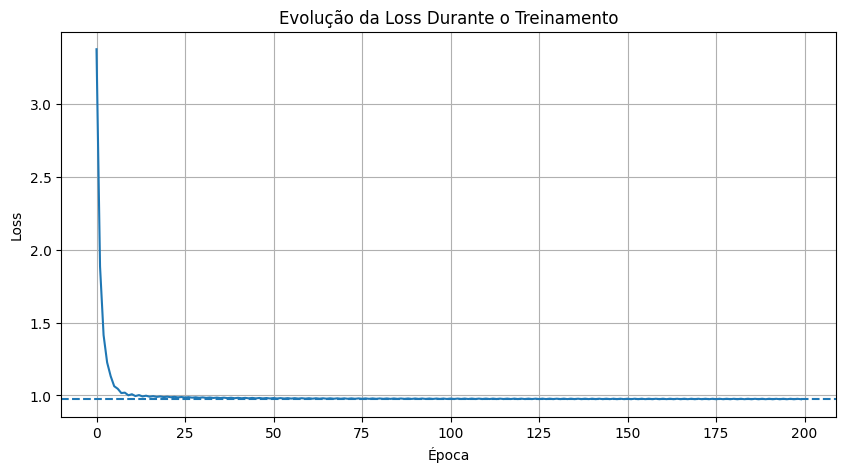

In [534]:
# ==================================================
# SEÇÃO 15 - VISUALIZANDO A LOSS
# ==================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(loss_history)

plt.axhline(
    loss_history[-1],
    linestyle="--"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.title(
    "Evolução da Loss Durante o Treinamento"
)

plt.grid(True)

plt.show()

#### Exercício de Reflexão

Observe o gráfico.

Perguntas:

- A loss diminui rapidamente no início?
- Em algum momento ela começa a estabilizar?
- Por que as melhorias ficam menores conforme o treinamento avança?

Pense no que aconteceria se continuássemos treinando indefinidamente.

#### Conceito Importante

Treinar uma rede neural significa encontrar um conjunto de pesos que minimize a loss.

O treinamento não acontece de uma vez.

Ele ocorre gradualmente:

```text
pesos aleatórios
      ↓
erro alto
      ↓
ajustes sucessivos
      ↓
erro menor
```

A curva de loss é uma das ferramentas mais importantes para acompanhar esse processo.

Em modelos modernos, ela é monitorada continuamente durante dias ou até semanas de treinamento.

---
### 16. Inspecionando o que a Rede Aprendeu

#### Objetivo

A loss diminuiu.

Isso significa que a rede aprendeu alguma coisa.

Mas o que exatamente está armazenado dentro da matriz de pesos?

Nesta seção vamos investigar os parâmetros aprendidos.

---

#### Relembrando a Matriz de Pesos

Nossa matriz possui formato:

```text
(vocab_size, vocab_size)
```

Cada linha representa:

```text
token atual
```

Cada coluna representa:

```text
próximo token possível
```

Exemplo:

```text
          a   b   c   d
a       1.2 0.3 2.1 0.5
b       0.1 3.2 0.7 1.8
c       ...
```

---

#### O Que os Valores Significam?

Importante:

Os pesos não são probabilidades.

Eles são apenas números aprendidos pela rede.

Podem ser:

```text
-3.5
0.2
7.8
-1.1
```

Quando aplicamos Softmax:

```python
probs = softmax(logits)
```

esses números são convertidos em probabilidades.

---

#### Uma Nova Interpretação

Após o treinamento:

- pesos altos → próximos tokens favorecidos
- pesos baixos → próximos tokens desfavorecidos

Portanto:

```text
Linha do token 'o'
```

passa a representar algo como:

```text
Depois de 'o',
quais caracteres a rede acredita
que costumam aparecer?
```

---

#### Exercício de Reflexão

Pergunta:

Se um determinado peso ficou muito positivo durante o treinamento:

```text
5.2
```

e outro ficou muito negativo:

```text
-4.7
```

Qual deles terá mais influência após o Softmax?

Pense nisso antes de continuar.

---

#### Conceito Importante

Durante o treinamento a rede não armazena regras.

Ela ajusta números.

O comportamento emerge desses ajustes.

Essa é uma característica fundamental das redes neurais:

> conhecimento é armazenado nos pesos.

In [535]:
# ==================================================
# INSPECIONANDO OS PESOS APRENDIDOS
# ==================================================

print("Shape da matriz:")
print(w.shape)

print()
print("Primeiras linhas:")
print()

print(w[:5, :5])

Shape da matriz:
torch.Size([16, 16])

Primeiras linhas:

tensor([[-2.4202, -0.2206,  0.2368, -0.2751, -0.2112],
        [-2.0174, -1.9564, -2.3239,  5.1278,  4.4329],
        [-1.8627,  4.7328, -1.6724,  4.8462, -2.0133],
        [-0.8290, -0.6436,  6.3256, -2.5570, -1.5612],
        [-1.0300,  0.2402, -0.2118, -0.2275, -0.5682]],
       grad_fn=<SliceBackward0>)


In [536]:
# ==================================================
# INSPECIONANDO UM TOKEN
# ==================================================

token_id = stoi['o']

print("Token:")
print(repr(itos[token_id]))

print()
print("Pesos aprendidos:")

print(w[token_id])

Token:
'o'

Pesos aprendidos:
tensor([ 4.7933,  3.8062, -1.9382, -1.8247, -1.8533, -2.5721, -2.5051, -1.9715,
         6.1077, -2.0887, -1.8958, -1.9682, -2.5705,  4.1253, -1.7927, -2.1984],
       grad_fn=<SelectBackward0>)


In [537]:
# ==================================================
# TOP PRÓXIMOS TOKENS
# ==================================================

import torch.nn.functional as F

token_id = stoi['o']

probs = F.softmax(
    w[token_id],
    dim=0
)

top_probs, top_ids = torch.topk(
    probs,
    k=10
)

for p, idx in zip(top_probs, top_ids):

    print(
        f"{repr(itos[idx.item()])} -> {p.item():.4f}"
    )

'l' -> 0.6623
'\n' -> 0.1779
'r' -> 0.0912
' ' -> 0.0663
't' -> 0.0002
'c' -> 0.0002
'd' -> 0.0002
'n' -> 0.0002
'a' -> 0.0002
'o' -> 0.0002


#### O Que Acabamos de Descobrir?

A rede aprendeu muito mais do que números aleatórios.

Agora cada linha da matriz contém informações sobre:

```text
token atual
↓
próximos tokens prováveis
```

Na prática, ela aprendeu uma versão neural da tabela de bigramas que construímos no notebook anterior.

A diferença é que:

- antes calculávamos contagens diretamente
- agora os padrões estão armazenados nos pesos aprendidos


---
### 17. Gerando Texto com o Modelo Treinado

#### Objetivo

Treinamos a rede.

A loss diminuiu.

Os pesos foram ajustados.

Agora finalmente vamos utilizar o modelo para aquilo que realmente queremos:

> gerar texto.

---

#### Relembrando o que a Rede Faz

Após o treinamento, a rede responde à pergunta:

```text
Dado o token atual,
qual é o próximo token mais provável?
```

Por exemplo:

```text
'o'
```

↓

```text
' ' -> 70%
'l' -> 20%
'r' -> 10%
```

---

#### Transformando Previsões em Texto

O processo é simples.

1. Escolhemos um token inicial
2. A rede calcula as probabilidades do próximo token
3. Sorteamos um token usando essas probabilidades
4. O token escolhido vira a nova entrada
5. Repetimos o processo

---

#### Processo Autoregressivo

Visualmente:

```text
Token atual
      ↓
    Rede
      ↓
Próximo token
      ↓
Nova entrada
      ↓
    Rede
```

Esse ciclo continua várias vezes.

Cada previsão influencia a próxima.

---

#### Por que Não Escolher Sempre o Mais Provável?

Imagine:

```text
a -> 90%
b -> 10%
```

Se sempre escolhermos o maior valor:

```text
a
```

o texto ficará extremamente repetitivo.

Por isso normalmente realizamos uma amostragem baseada nas probabilidades.

Tokens mais prováveis aparecem com mais frequência.

Mas não aparecem sempre.

---

#### Exercício de Reflexão

Antes de executar:

Perguntas:

- O modelo produzirá sempre o mesmo texto?
- O que acontece se executarmos várias vezes?
- Como a aleatoriedade influencia o resultado?

Pense nisso antes de continuar.

---

#### Conceito Importante

A geração de texto em modelos modernos segue exatamente esse princípio.

A diferença é que GPTs utilizam muito mais contexto para calcular as probabilidades.

Mas a mecânica básica continua sendo:

```text
Prever próximo token
↓
Adicionar ao contexto
↓
Prever novamente
```

In [538]:
# ==================================================
# SEÇÃO 17 - GERAÇÃO DE TEXTO
# ==================================================

import torch
import torch.nn.functional as F


def generate(max_tokens=100):

    current_token = data[0]

    generated = [
        current_token.item()
    ]

    for _ in range(max_tokens):

        logits = w[current_token]

        probs = F.softmax(
            logits,
            dim=0
        )

        next_token = torch.multinomial(
            probs,
            num_samples=1
        ).item()

        generated.append(next_token)

        current_token = torch.tensor(
            next_token
        )

    return decode(generated)

In [539]:
print(generate())

olatiu
ola dola cholatgatgptolatolatiu
o
olatgatgptolatolatgptiundolatgptgptiu
olatgptgptolatiu
olatg


#### O Que Acabamos de Fazer?

Pela primeira vez utilizamos a rede neural como um modelo de linguagem completo.

Ela recebe um token.

Calcula probabilidades.

Escolhe o próximo token.

E repete esse processo sucessivamente.

---

#### O Que Mudou em Relação ao Notebook 01?

No notebook anterior:

```text
contagens
→ probabilidades
→ geração
```

Agora temos:

```text
pesos
→ logits
→ softmax
→ probabilidades
→ geração
```

O resultado parece semelhante.

Mas a forma como o conhecimento é armazenado mudou completamente.

---

#### Limitação Atual

Nosso modelo continua sendo um bigrama.

Ele enxerga apenas:

```text
1 token de contexto
```

Portanto ainda não consegue capturar dependências longas.

Resolver esse problema será justamente o foco dos próximos notebooks.